Dean Hickman

Fall 2024

CS 251: Data Analysis and Visualization

# Lab 4b | Principal Component Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
import pandas as pd

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-dark'])
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'figure.figsize': [6,6]})

np.set_printoptions(suppress=True, precision=5)

## Task 1: Visualize PCA for a 2D dog data set

The goal of this lab is for you to gain experience visualizing the covariance matrix and principal components. We begin with a data set that has the mid-range value for height (in inches) and weight (in pounds) for each of 146 dog breeds. The data set was constructed from part of a data set made available on Kaggle (https://www.kaggle.com/datasets/jasleensondhi/dog-intelligence-comparison-based-on-size).

### Task 1a: Scatter plot the original and normalized data

1. Use pandas to read data/AKC_Breed_Inof_mid.csv in a data fram
2. Examine the contents of the data frame
3. Make a data frame that has just the weight (first) and height (second) columns. You can do that by indexing into the data frame with the list `['weight_mid_lbs','height_mid_inches']`. Store it in a variable named `x_df`
4. Scatter plot the height vs weight (i.e. height on y-axis, weight on x-axis)
5. Normalize ths columns by subtracting the min and then dividing the difference by the max minus min (storing the result in `x_df`). Note that since you are operating with a data frame, you do not need to supply axis information - it will automatically apply the operation along each column.
6. In a new figure, scatter plot the normalized height vs weight.

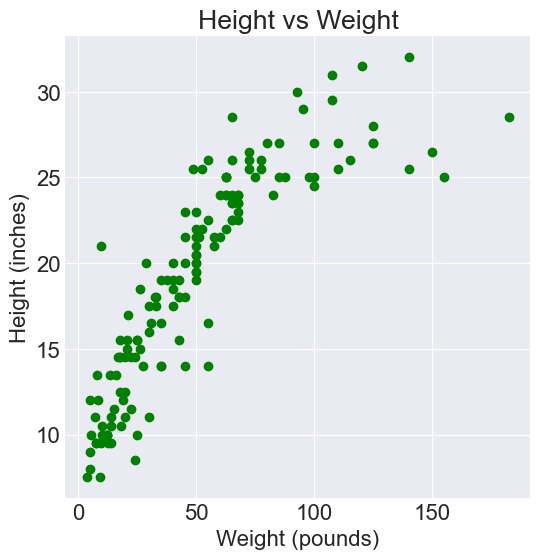

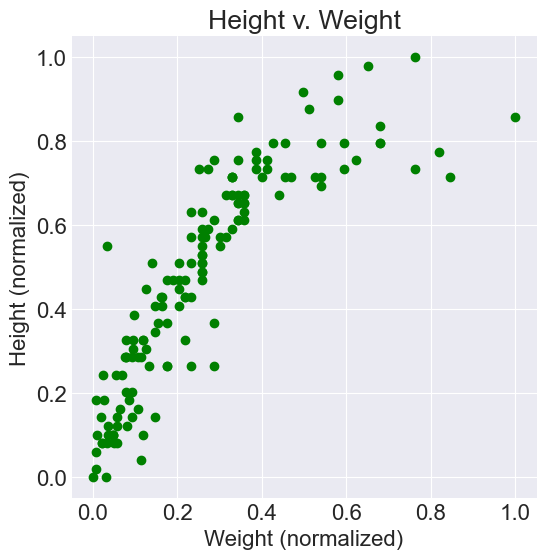

In [5]:
file = 'data/AKC_Breed_Info_mid.csv'
df = pd.read_csv(file)
df.head()

x_df = df[['weight_mid_lbs','height_mid_inches']]

plt.scatter(x_df['weight_mid_lbs'], x_df['height_mid_inches'], color='green')
plt.title('Height vs Weight')
plt.xlabel('Weight (pounds)')
plt.ylabel('Height (inches)')
plt.grid()
plt.show()

x_normalized = (x_df-x_df.min())/(x_df.max()-x_df.min())
plt.scatter(x_normalized['weight_mid_lbs'], x_normalized['height_mid_inches'], color='green')
plt.title('Height v. Weight')
plt.xlabel('Weight (normalized)')
plt.ylabel('Height (normalized)')
plt.grid()
plt.show()

### 1b. Create and visualize a covariance matrix

1. Use the [Dataframe](https://pandas.pydata.org/pandas-docs/stable/reference/frame.html) documentation to find out how to compute the covariance matrix of the `x_df` columns, store it in a variable, and print its shape.
2. Use the [matplotlib](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html) and [imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html) documentation to visualize the covariance matrix with a heatmap.
    1. Include a title
    2. Include labels for each row and column 
        1. Set the xticks, yticks, xticklabels and ytickslabels. When setting the xtick labels, rotate them so they are readable and horizontally align them to the right (i.e. `ha='right'`). You can also use `setp` to handle rotating the x-axis tick labels.
    3. Use an perceptually uniform sequential [colormap](https://matplotlib.org/tutorials/colors/colormaps.html). 
        1. Set it using the `cmap` parameter for `imshow`
    4. Include a `colorbar`. This can be achieved by assigning a variable to your `imshow` call and then passing in that variable as a parameter to `plt.colorbar`. If that does not work, the [this example code](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html#using-the-helper-function-code-style) may be helpful.

*Your heatmap should show a 2x2 grid of colored squares.*

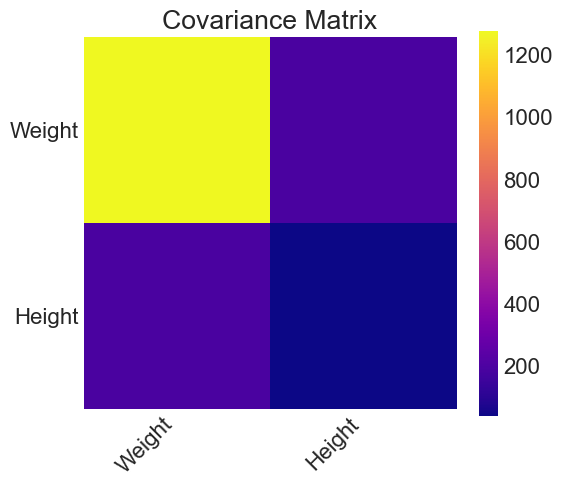

In [9]:
cov_matrix = x_df.cov()
plt.figure(figsize=(6,5))
plot = plt.imshow(cov_matrix, cmap='plasma')
plt.title('Covariance Matrix')
xticks = ['Weight', 'Height']
yticks = ['Weight', 'Height']
plt.xticks(ticks=[0,1], labels=xticks, rotation=45, ha='right')
plt.yticks(ticks=[0,1], labels=yticks)
plt.colorbar(plot)
plt.show()

### 1c. Questions

**Question 1:** What interpretations can you draw from this covariance matrix?

**Answer 1:** On the main diagonal there is high variance in weight and not so much (almost none) in height. The off diagonal highlights that there may be a weak linear relationship between the variables but does ensure that the matrix is symmetric.

### 1d. Performing PCA

Use Sci-kit Learn's [PCA class](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) to apply PCA to the dog dataset.
1. Create an instance of the PCA class with 2 components. *This means that we will compute all the principal components (eigenvectors of the covariance matrix) for our 2-D data set*.
2. Call the method `fit_` with `x_df` as the X parameter.
3. Store the transpose of the `components_` field of the PCA object in an variable named e_vecs. Then print it. The output should be

`[[ 0.6031   0.79766]
 [ 0.79766 -0.6031 ]]`

Each column of `e_vecs` is a principal component.

4. Store the `explained_variance_` field of the PCA object in a variable named `e_vals`. The first entry in `e_vals` is the eigen-value associated with the first column of `e_vecs`. Print the values. They should be `[0.09758 0.00696]`

In [11]:
from sklearn.decomposition import PCA

In [15]:
pca = PCA(n_components = 2)
pca.fit(x_normalized)

e_vecs = pca.components_.T
print("Principal Components:")
print(e_vecs)

e_vals = pca.explained_variance_
print("Eigenvalues:")
print(e_vals)

Principal Components:
[[ 0.6031   0.79766]
 [ 0.79766 -0.6031 ]]
Eigenvalues:
[0.09758 0.00696]


### 1e. Visualize the vectors on the scatter plot

When we perform PCA in just two dimensions, it is helpful to plot the eigenvectors as vectors on the scatter plot, so we can clearly identify the primary and secondary directions of variation in the data. The vectors should start at the center of the data and their lengths should be proportional to their associated eigenvalues (so we can capture the relative importance of the directions). You should think of the entries in the eigenvectors as slopes. For the sake of simplicity (and time), I have worked out the scale you should use for this example (it is 8).

1. Compute the center of the data and store it as a numpy array (rather than as a data frame): `center = x_df.mean().to_numpy()`
2. Scatter plot the columns of x_df as above (copy-paste your code)
3. Using the `plot` function, plot the first vector. Provide x-coordinates for the beginning of the line (`center[0]`) and the end, which is computed by adding 8 times the first `e_val` times the x-coordinate of the first eigenvector (i.e. `e_vec[0,0]`). Provide the y-coordinates for the begining (`center[1]`) and end, which is computed by adding 8 times the first `e_val` times the y-coordinate of the first eigenvector (i.e. `e_vec[1,0]`)
4. Plot the second vector in a similar fashion. Just use the second egeinvalue and second eigenvector instead of the first.

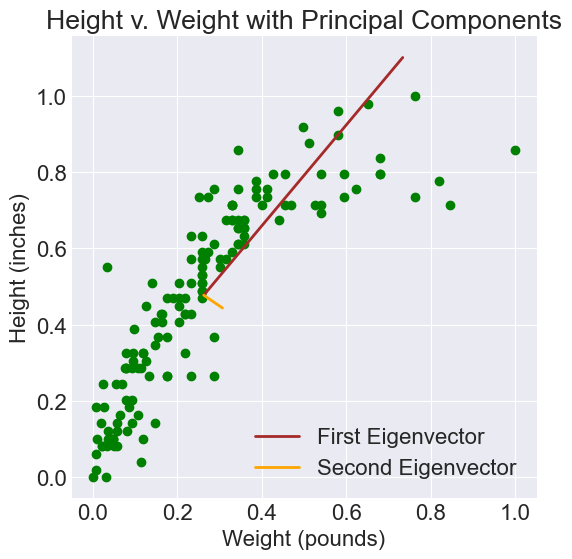

In [19]:
center = x_normalized.mean().to_numpy()

plt.scatter(x_normalized['weight_mid_lbs'], x_normalized['height_mid_inches'], color='green')

plt.plot(
    [center[0], center[0] + 8 * e_vals[0] * e_vecs[0, 0]],
    [center[1], center[1] + 8 * e_vals[0] * e_vecs[1, 0]],
    color='brown', linewidth = 2, label="First Eigenvector"
)

plt.plot(
    [center[0], center[0] + 8 * e_vals[1] * e_vecs[0, 1]],
    [center[1], center[1] + 8 * e_vals[1] * e_vecs[1, 1]],
    color='orange', linewidth = 2, label="Second Eigenvector"
)

plt.title('Height v. Weight with Principal Components')
plt.xlabel('Weight (pounds)')
plt.ylabel('Height (inches)')
plt.legend()
plt.grid(True)
plt.show()

### 1f. Visualize the PCA loadings as a heat map

When we have more than 2 dimensions, we need to use alternate forms of visualization, so let's look at an alternate method now, so we can compare it to the vector version about. We introduce a new term -- **loadings**. In PCA, the **loadings** refer to the numbers that make up the principal component vectors (i.e. the eigenvectors). The shape of the loadings (eigenvectors) are `(k, M)` where `k` is the number of PCs and `M` is the number of original variables in the dataset. This task focuses on visualizing and interpreting what the loadings mean.

Use [imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html) to make a heatmap of the loadings (which are in `e_vecs`).
   
1. Include a title.
2. Set the `xticks`, `yticks`, `xticklabels` and `ytickslabels`. The y tick labels (rows) should show the original 2 variable names. The 2 x tick labels should be labeled with `'PC1'` and `'PC2'`.
3. Use an perceptually uniform **diverging** [colormap](https://matplotlib.org/tutorials/colors/colormaps.html). Set it using the `cmap` parameter for `imshow`.
4. To ensure that 0 is indicated by the neutral/middle color in the colormap, we need the data to be color-mapped using a range that is centered on zero. Compute the magnitude of the loadings (the maximim absolute loading). If you store that magnitude in a variable, named `mag`, then you can add the parameter and value to the imshow call: `norm=matplotlib.colors.Normalize(-mag,mag)`.
5. Include a `colorbar`. This can be achieved by assigning a variable to your `imshow` call and then passing in that variable as a parameter to `plt.colorbar`. If that does not work, the [this example code](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html#using-the-helper-function-code-style) may be helpful.

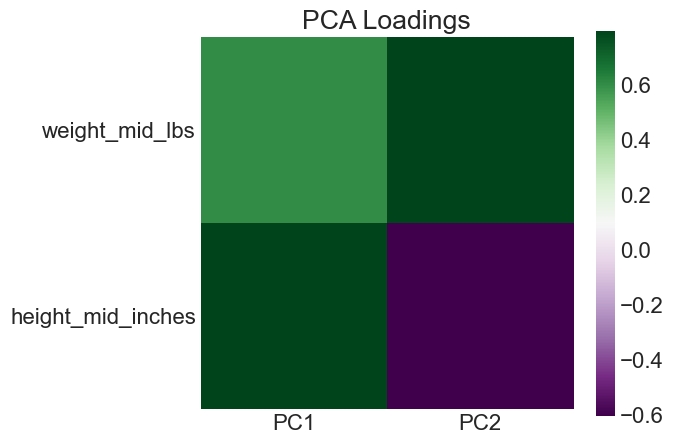

In [39]:
plt.figure(figsize=(6,5))
mag = np.max(np.abs(e_vals))
plot = plt.imshow(e_vecs, cmap='PRGn')
plt.title('PCA Loadings')
xticks = ['PC1', 'PC2']
yticks = ['weight_mid_lbs', 'height_mid_inches']
plt.xticks(ticks=[0,1], labels=xticks)
plt.yticks(ticks= [0,1], labels=yticks)
plt.colorbar(plot)
plt.show()

### 1g. Questions

**Question 2:** Interpret the loadings of PC1 and PC2 by relating them to the vector plot above. Also, does height or weight play a larger role in the first vector? 

**Answer 2:** The first principal component is a combination of the weight and height variance, both variables contribute to the loadings equally. The second principal component shows the differences between these variables and how the vary opposite of each other, you can see this in the loading plot. The colors are on opposite sides of the scale.

## Task 2: PCA on a cancer data set

### 2a. Load and preprocess

To get a tate of PCA for a larger data set, we will use the [Wisconsin Breast Cancer dataset](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Original)) this week. To keep the lab assignment manageable, we provide some of the code (you can think of the instructions as explanations of the code, in this case).

1. Import dataset using pandas [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) to create a Dataframe from the url:  https://raw.githubusercontent.com/patrickmlong/Breast-Cancer-Wisconsin-Diagnostic-DataSet/master/data.csv
2. Create a `cancer_x` DataFrame which includes all of the columns that have the word "mean" in the title (*there should be 10 in total*).
3. Print out a summary of the `cancer_x` DataFrame.
4. Update `cancer_x` so that each variable is min-max normalized. Print out a summary of the updated DataFrame.
5. `diagnosis` is a categorical variable (`M` stands for "malignant" and `B` stands for "benign"). Create a `cancer_y` Series with from the column `diagnosis` and convert the data type to [categorical](https://pandas.pydata.org/docs/user_guide/categorical.html).
    1. In Task 2 of this lab you will use `diagnosis` to color-code a scatter plot of the cancer data. Use [rename_categories](https://pandas.pydata.org/pandas-docs/stable/user_guide/categorical.html#renaming-categories) to replace the categorical levels with color string names. To do this, pass in a dictionary as the parameter that maps the strings `'M'` and `'B'` to [colors](https://matplotlib.org/stable/gallery/color/named_colors.html) of your choice (e.g. `'red'`, `'blue'`). By default, the `rename_categories` method doesn't update the DataFrame when you call it, so don't forget to update the value of `cancer_y` by assigning it to the output of your `rename_categories` method call.
    2. Print out `cancer_y`. You should see the `dtype` as `category` and the values should be one of two named color strings (e.g. `'red'`, `'blue'`).

In [40]:
url="https://raw.githubusercontent.com/patrickmlong/Breast-Cancer-Wisconsin-Diagnostic-DataSet/master/data.csv"

# Note that if it does not work for you to read the file directly
# from the internet, then follow the link in a browser, download the file, 
# and read it directly from your computer
cancer_data = pd.read_csv(url) 

x_names = ['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']
cancer_x = cancer_data[x_names]
print('Means of cancer_x:\n', cancer_x.mean())

cancer_x = (cancer_x-cancer_x.min())/(cancer_x.max()-cancer_x.min())
cancer_y = cancer_data['diagnosis'].astype('category')
cancer_y = cancer_y.cat.rename_categories({'M': 'red', 'B': 'blue'})
print(cancer_y)

Means of cancer_x:
 radius_mean                14.127292
texture_mean               19.289649
perimeter_mean             91.969033
area_mean                 654.889104
smoothness_mean             0.096360
compactness_mean            0.104341
concavity_mean              0.088799
concave points_mean         0.048919
symmetry_mean               0.181162
fractal_dimension_mean      0.062798
dtype: float64
0       red
1       red
2       red
3       red
4       red
       ... 
564     red
565     red
566     red
567     red
568    blue
Name: diagnosis, Length: 569, dtype: category
Categories (2, object): ['blue', 'red']


### 2b. Visualize with pair-plots

Scatter plot the data with every pair of features, using the diagnosis for the color. Label the y-axis of the first column and the x-axis of the bottom row with the feature names. Do not use any x- or y-ticks.

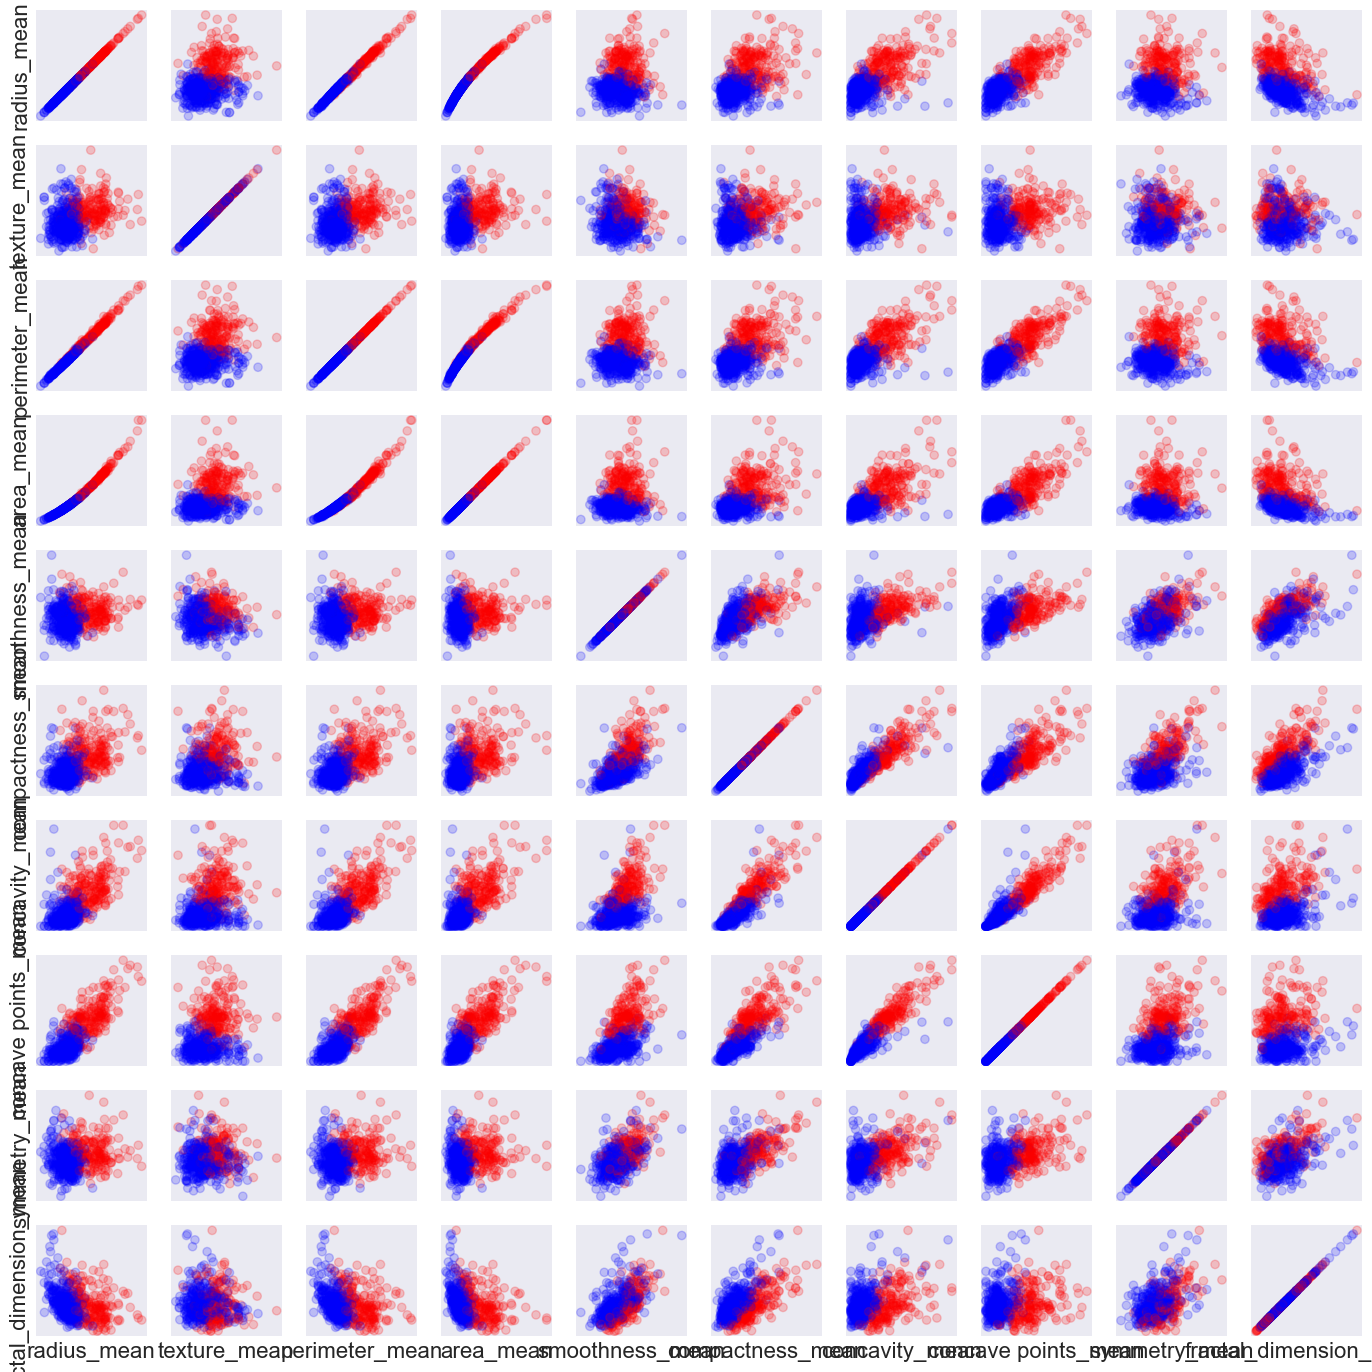

In [44]:
# pair plot
plt.figure( figsize=(14,14))
cx = cancer_x.to_numpy()
for row_idx in range(cx.shape[1]):
    for col_idx in range(cx.shape[1]):
        plt.subplot( cx.shape[1], cx.shape[1], row_idx*cx.shape[1]+col_idx+1 )
        plt.scatter( cx[:,col_idx], cx[:,row_idx], color=cancer_y, alpha=0.2 )
        plt.xticks([])
        plt.yticks([])
        if row_idx == cx.shape[1]-1:
            plt.xlabel( x_names[col_idx] )
        if col_idx == 0:
            plt.ylabel( x_names[row_idx])
plt.tight_layout()
plt.show()

### 2c. Create and visualize a covariance matrix

1. Use the [Dataframe](https://pandas.pydata.org/pandas-docs/stable/reference/frame.html) documentation to find out how to compute the covariance matrix of the `cancer_x` columns, store it in a variable, and print its shape.
2. Use the [matplotlib](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html) and [imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html) documentation to visualize the covariance matrix with a heatmap.
    1. Include a title
    2. Include labels for each row and column 
        1. Set the xticks, yticks, xticklabels and ytickslabels. When setting the xtick labels, rotate them so they are readable and horizontally align them to the right (i.e. `ha='right'`). You can also use `setp` to handle rotating the x-axis tick labels.
    3. Use an perceptually uniform sequential [colormap](https://matplotlib.org/tutorials/colors/colormaps.html). 
        1. Set it using the `cmap` parameter for `imshow`
    4. Include a `colorbar`. This can be achieved by assigning a variable to your `imshow` call and then passing in that variable as a parameter to `plt.colorbar`. If that does not work, the [this example code](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html#using-the-helper-function-code-style) may be helpful.

*Your heatmap should show a 10x10 grid of colored squares.*

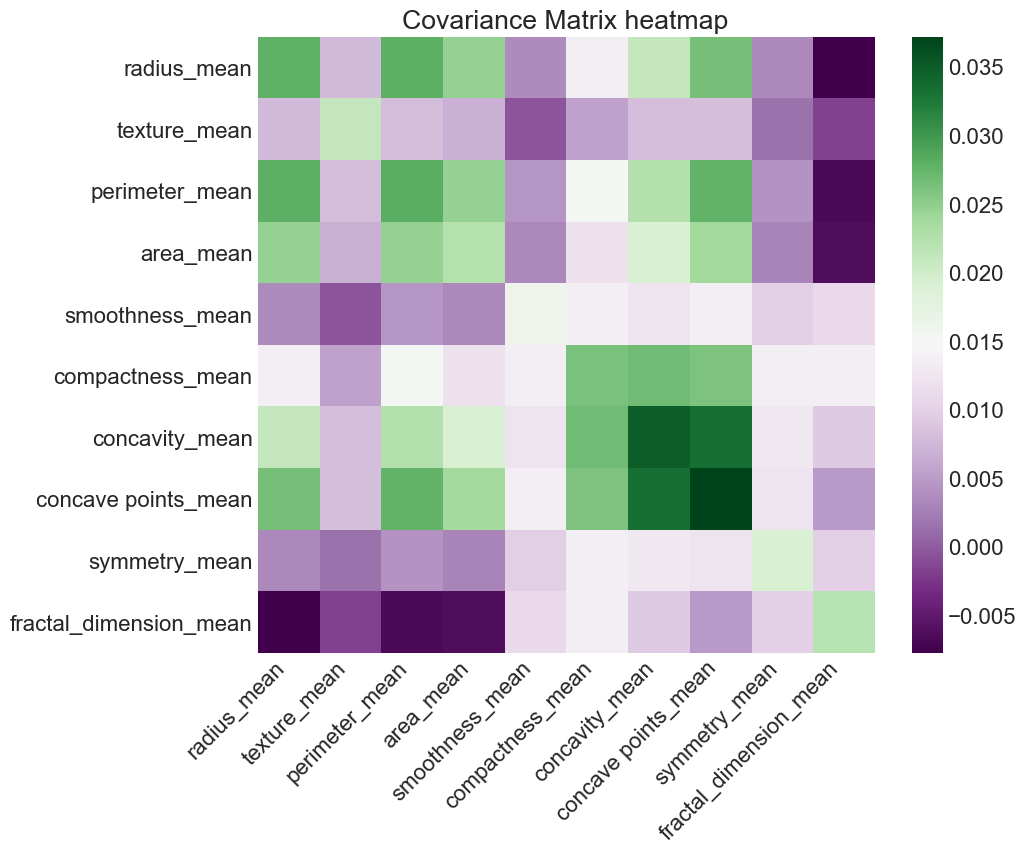

In [48]:
cov_matrix = cancer_x.cov()
plt.figure(figsize=(10,8))
plot = plt.imshow(cov_matrix, cmap='PRGn')
plt.title('Covariance Matrix heatmap')
plt.xticks(ticks=np.arange(len(x_names)), labels=x_names, rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(x_names)), labels=x_names)
plt.colorbar(plot)
plt.show()

### 2d. Questions

**Question 3:** What interpretations can you draw from this covariance matrix?

**Answer 3:** There are a lot of positive covariances in this matrix specifically things around shape and size. It is easier to talk about the things that had little covariance like fractal_dimension_mean. These interactions highlight that with a lot of variables you can measure more relationships and visualize interactions that might have otherwise been missed. 

### 2c. Performing PCA

Use Sci-kit Learn's [PCA class](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) to apply PCA to the cancer dataset.
1. Create an instance of the PCA class with `len(x_names)` components. *This means that we will compute all 10 eigenvectors in our 10-D data set*.
2. Call the method `fit_` with `cancer_x` as the X parameter.
3. Store the transpose of the `components_` field of the PCA object in an variable named e_vecs. Print the shape to verify it is `(10,10)`. Note that each column of `e_vecs` is a principal component.
4. Store the `explained_variance_` field of the PCA object in a variable named `e_vals`. The first entry in `e_vals` is the eigen-value associated with the first column of `e_vecs`, etc. Print the values. There should be 10.

In [53]:
pca = PCA(n_components=len(x_names))
pca.fit(cancer_x)
e_vecs = pca.components_.T
e_vals = pca.explained_variance_
print(f"Eigenvalues:\n {e_vals}")

Eigenvalues:
 [0.15632 0.05609 0.01875 0.01012 0.00688 0.00348 0.00206 0.00121 0.00027
 0.00001]


### 2d. Visualize the PCA loadings

As above, plot the loadings for all of the principal components.

1. Print out the shape of the loadings (`e_vecs`). 
2. Use [imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html) to make a heatmap of the loadings. You should plot the **transposed** loadings, which will make your plot more readable — i.e. your heatmap should be taller than it is wide.
   1. Make the figure large enough that all the tick labels will fit (e.g. width of 12). Also, include a title.
   2. Set the `xticks`, `yticks`, `xticklabels` and `ytickslabels`. The y tick labels (rows) should show the original 10 variable names. The x tick labels should be labeled with `'PC1'`, `'PC2'`, ..., `'PC10'`.
   3. Use an perceptually uniform **diverging** [colormap](https://matplotlib.org/tutorials/colors/colormaps.html). Set it using the `cmap` parameter for `imshow`.
   4. To ensure that 0 is indicated by the neutral/middle color in the colormap, we need the data to be color-mapped using a range that is centered on zero. Compute the magnitude of the loadings (the maximim absolute loading). If you store that magnitude in a variable, named `mag`, then you can add the parameter and value to the imshow call: `norm=matplotlib.colors.Normalize(-mag,mag)`.
   5. Include a `colorbar`. This can be achieved by assigning a variable to your `imshow` call and then passing in that variable as a parameter to `plt.colorbar`. If that does not work, the [this example code](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html#using-the-helper-function-code-style) may be helpful.

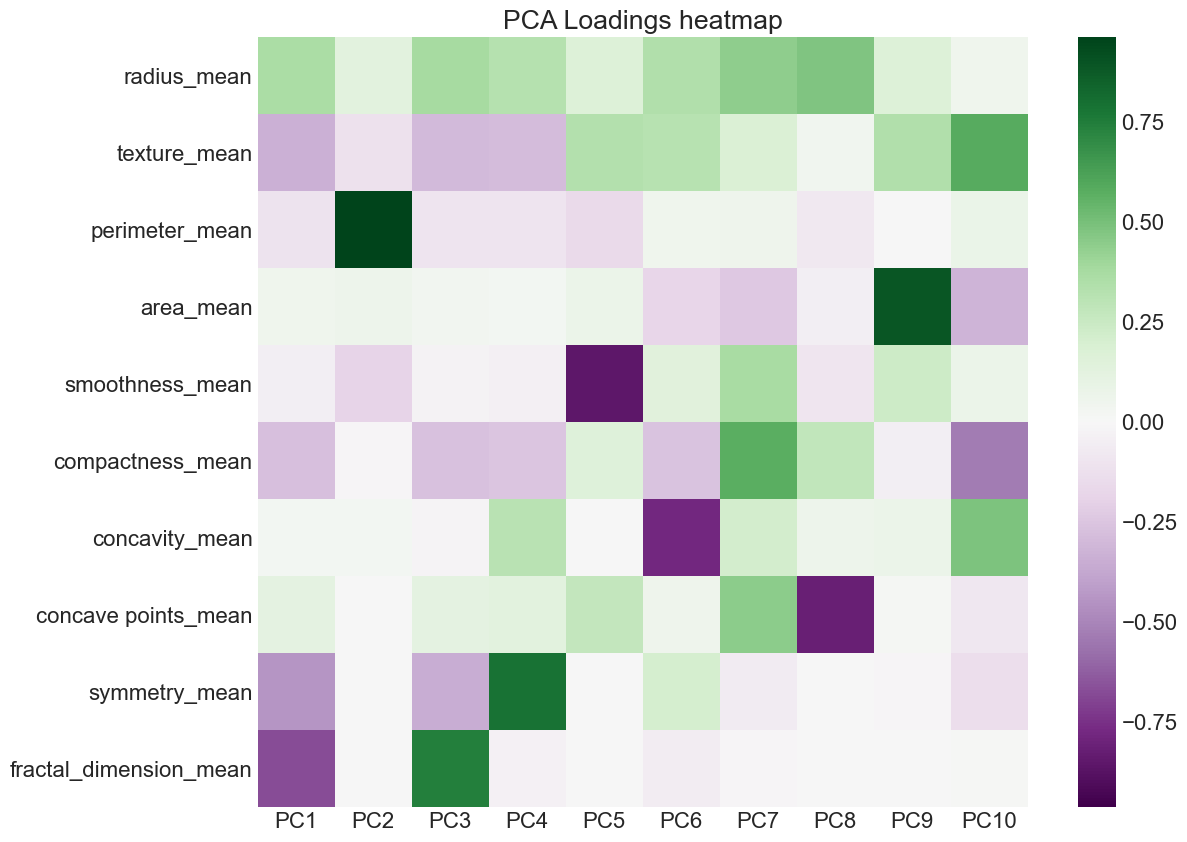

In [57]:
mag = np.max(np.abs(e_vecs))
plt.figure(figsize=(13, 10))
plot = plt.imshow(e_vecs.T, cmap='PRGn', norm=matplotlib.colors.Normalize(-mag, mag))
plt.xticks(ticks=np.arange(len(e_vecs.T)), labels=[f'PC{i+1}' for i in range(len(e_vecs.T))])
plt.yticks(ticks=np.arange(len(x_names)), labels=x_names)
plt.title('PCA Loadings heatmap')
plt.colorbar(plot)
plt.show()

### 2e. Questions

**Question 4:** Interpret the loadings of PC1 and PC2. Which variables in the cancer dataset are most positively and negatively correlated with each PC?

**Answer 4:** The most positively correlated variables in PC1 is radius_mean and in PC2 its perimeter_mean. The most negatively correlated variables in PC1 is fractal_dimension_mean and PC2 smoothness_mean. The variables with the most positive values contribute the most to their respective PC's and those with the most negative values contribute the least, and inversely to their respective PC's.

## Turn in your lab

Follow the usual submission format and submit your lab on Google Classroom.